### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
from dotenv import load_dotenv
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

def get_connection():
    connection_string = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={os.getenv('DB_SERVER')},1433;"
        f"DATABASE={os.getenv('DB_NAME')};"
        f"UID={os.getenv('DB_USERNAME')};"
        f"PWD={os.getenv('DB_PASSWORD')};"
        f"Encrypt=yes;"
        f"TrustServerCertificate=no;"
        f"Connection Timeout=30;"
    )
    return pyodbc.connect(connection_string)

conn = get_connection()
print("✅ Connected to Azure SQL!")

✅ Connected to Azure SQL!


###  Load Data and Build Team Features

In [2]:
matches_full_df = pd.read_sql("""
    SELECT 
        m.match_id, m.match_date, m.group_name,
        t1.team_name as home_team, t1.fifa_code as home_code,
        m.home_score, m.away_score,
        t2.team_name as away_team, t2.fifa_code as away_code
    FROM matches m
    JOIN teams t1 ON m.home_team_id = t1.team_id
    JOIN teams t2 ON m.away_team_id = t2.team_id
    WHERE m.home_score IS NOT NULL
""", conn)

teams_df = pd.read_sql("SELECT * FROM teams", conn)

print(f"✅ Loaded {len(matches_full_df)} completed matches")
print(f"✅ Loaded {len(teams_df)} teams")

def build_team_stats(matches_df):
    stats = {}
    for _, match in matches_df.iterrows():
        home, away = match['home_team'], match['away_team']
        hg, ag = int(match['home_score']), int(match['away_score'])
        group = match['group_name'].replace('GROUP_', '')
        
        for team, gf, ga, is_home in [(home, hg, ag, 1), (away, ag, hg, 0)]:
            if team not in stats:
                stats[team] = {
                    'team': team, 'group': group, 'played': 0,
                    'won': 0, 'drawn': 0, 'lost': 0,
                    'goals_for': 0, 'goals_against': 0, 'points': 0,
                    'home_games': 0, 'clean_sheets': 0,
                    'failed_to_score': 0, 'biggest_win': 0, 'momentum': []
                }
            s = stats[team]
            s['played'] += 1
            s['goals_for'] += gf
            s['goals_against'] += ga
            s['home_games'] += is_home
            if ga == 0: s['clean_sheets'] += 1
            if gf == 0: s['failed_to_score'] += 1
            margin = gf - ga
            if margin > s['biggest_win']: s['biggest_win'] = margin
            if gf > ga:
                s['won'] += 1; s['points'] += 3; s['momentum'].append(3)
            elif gf == ga:
                s['drawn'] += 1; s['points'] += 1; s['momentum'].append(1)
            else:
                s['lost'] += 1; s['momentum'].append(0)
    
    for team, s in stats.items():
        p = s['played']
        s['goal_difference'] = s['goals_for'] - s['goals_against']
        s['goals_per_game'] = round(s['goals_for'] / p, 2) if p > 0 else 0
        s['goals_conceded_per_game'] = round(s['goals_against'] / p, 2) if p > 0 else 0
        s['win_rate'] = round(s['won'] / p, 2) if p > 0 else 0
        s['points_per_game'] = round(s['points'] / p, 2) if p > 0 else 0
        momentum = s['momentum']
        if len(momentum) > 0:
            weights = np.array([0.5, 0.3, 0.2][:len(momentum)])
            weights = weights / weights.sum()
            recent = momentum[-3:]
            w = weights[-len(recent):] / weights[-len(recent):].sum()
            s['momentum_score'] = round(float(np.dot(recent, w)), 2)
        else:
            s['momentum_score'] = 0
    
    return pd.DataFrame(stats.values())

team_stats_df = build_team_stats(matches_full_df)
print(f"\n✅ Built features for {len(team_stats_df)} teams")
team_stats_df.sort_values('points', ascending=False).head(10)

✅ Loaded 47 completed matches
✅ Loaded 48 teams

✅ Built features for 48 teams


,team,group,played,won,drawn,lost,goals_for,goals_against,points,home_games,clean_sheets,failed_to_score,biggest_win,momentum,goal_difference,goals_per_game,goals_conceded_per_game,win_rate,points_per_game,momentum_score
0,Mexico,A,2,2,0,0,3,0,6,2,2,0,2,"[3, 3]",3,1.5,0.0,1.0,3.0,3.00
6,United States,D,2,2,0,0,6,1,6,2,1,0,3,"[3, 3]",5,3.0,0.5,1.0,3.0,3.00
36,Argentina,J,2,2,0,0,5,0,6,2,2,0,3,"[3, 3]",5,2.5,0.0,1.0,3.0,3.00
16,Germany,E,2,2,0,0,9,2,6,2,0,0,6,"[3, 3]",7,4.5,1.0,1.0,3.0,3.00
32,France,I,2,2,0,0,6,1,6,2,1,0,3,"[3, 3]",5,3.0,0.5,1.0,3.0,3.00
35,Norway,I,2,2,0,0,7,3,6,1,0,0,3,"[3, 3]",4,3.5,1.5,1.0,3.0,3.00
4,Canada,B,2,1,1,0,7,1,4,2,1,0,6,"[1, 3]",6,3.5,0.5,0.5,2.0,1.75
9,Switzerland,B,2,1,1,0,5,2,4,1,0,0,3,"[1, 3]",3,2.5,1.0,0.5,2.0,1.75
24,Spain,H,2,1,1,0,4,0,4,2,2,1,4,"[1, 3]",4,2.0,0.0,0.5,2.0,1.75
19,Japan,F,2,1,1,0,6,2,4,0,1,0,4,"[1, 3]",4,3.0,1.0,0.5,2.0,1.75


###  FIFA Rankings

In [3]:
# ============================================
# ADD FIFA RANKINGS (Manual — Nov 2025 rankings)
# Used for seeding at this tournament
# ============================================

fifa_rankings = {
    'France': 2, 'Spain': 3, 'England': 4, 'Brazil': 5,
    'Portugal': 6, 'Netherlands': 7, 'Argentina': 8,
    'Belgium': 9, 'Germany': 10, 'Morocco': 13,
    'United States': 14, 'Mexico': 15, 'Switzerland': 16,
    'Croatia': 17, 'Uruguay': 18, 'Colombia': 19,
    'Japan': 20, 'Ecuador': 21, 'Senegal': 22,
    'Sweden': 23, 'South Korea': 24, 'Turkey': 25,
    'Australia': 26, 'Canada': 27, 'Saudi Arabia': 28,
    'Egypt': 31, 'Austria': 32, 'South Africa': 64,
    'Ghana': 54, 'Tunisia': 30, 'Ivory Coast': 48,
    'Norway': 34, 'Scotland': 38, 'Czech Republic': 40,
    'Czechia': 40, 'Iran': 20, 'Qatar': 35,
    'Bosnia-Herzegovina': 55, 'Paraguay': 58,
    'Algeria': 42, 'New Zealand': 100, 'Jordan': 87,
    'Iraq': 63, 'Uzbekistan': 50, 'Congo DR': 56,
    'Cape Verde Islands': 80, 'Haiti': 83,
    'Curaçao': 85, 'Panama': 70
}

team_stats_df['fifa_ranking'] = team_stats_df['team'].map(fifa_rankings).fillna(90)
team_stats_df['ranking_tier'] = pd.cut(
    team_stats_df['fifa_ranking'],
    bins=[0, 10, 25, 50, 100, 200],
    labels=['Elite', 'Strong', 'Mid', 'Lower', 'Minnow']
)

print("✅ FIFA Rankings added!")
print(f"\n📊 Teams by Ranking Tier:")
print(team_stats_df.groupby('ranking_tier')['team'].count())
print(f"\n🏆 Top 10 Ranked Teams in Tournament:")
top_ranked = team_stats_df.sort_values('fifa_ranking').head(10)[
    ['team', 'fifa_ranking', 'points', 'goal_difference', 'goals_per_game']
]
print(top_ranked.to_string(index=False))

✅ FIFA Rankings added!

📊 Teams by Ranking Tier:
ranking_tier
Elite      9
Strong    14
Mid       13
Lower     12
Minnow     0
Name: team, dtype: int64

🏆 Top 10 Ranked Teams in Tournament:
       team  fifa_ranking  points  goal_difference  goals_per_game
     France             2       6                5             3.0
      Spain             3       4                4             2.0
    England             4       4                2             2.0
     Brazil             5       4                3             2.0
   Portugal             6       4                5             3.0
Netherlands             7       4                4             3.5
  Argentina             8       6                5             2.5
    Belgium             9       2                0             0.5
    Germany            10       6                7             4.5
    Morocco            13       4                1             1.0


###  Historical Training Data

In [4]:
import requests
import time

API_KEY = os.getenv('FOOTBALL_API_KEY')
BASE_URL = "https://api.football-data.org/v4"
HEADERS = {"X-Auth-Token": API_KEY}

# Verified 2018 World Cup data — FIFA official match records
verified_2018 = [
    # Team, Pts, GD, GF, Ranking, Advanced
    ('Uruguay', 9, 5, 5, 14, 1), ('Russia', 6, 5, 8, 70, 1),
    ('France', 7, 3, 3, 7, 1), ('Denmark', 5, 2, 3, 12, 1),
    ('Croatia', 7, 5, 7, 20, 1), ('Argentina', 4, 0, 3, 5, 1),
    ('Brazil', 7, 4, 5, 2, 1), ('Switzerland', 5, 1, 5, 6, 1),
    ('Belgium', 9, 7, 8, 3, 1), ('Japan', 4, 0, 4, 61, 1),
    ('Sweden', 6, 4, 6, 24, 1), ('Mexico', 6, 2, 3, 15, 1),
    ('Colombia', 6, 3, 5, 16, 1), ('England', 6, 5, 8, 13, 1),
    ('Senegal', 4, 0, 4, 27, 1), ('Nigeria', 3, -1, 3, 48, 1),
    ('Poland', 3, -2, 2, 8, 0), ('Germany', 3, -2, 2, 1, 0),
    ('Portugal', 5, 1, 4, 4, 0), ('Spain', 5, 1, 4, 10, 0),
    ('Iran', 4, 0, 2, 37, 0), ('Peru', 0, -4, 2, 11, 0),
    ('Morocco', 1, -1, 2, 48, 0), ('Iceland', 1, -3, 2, 22, 0),
    ('Australia', 1, -3, 2, 41, 0), ('Saudi Arabia', 1, -4, 2, 67, 0),
    ('Egypt', 0, -4, 2, 45, 0), ('Tunisia', 1, -2, 5, 21, 0),
    ('Panama', 0, -7, 2, 55, 0), ('South Korea', 3, -3, 3, 57, 0),
    ('Costa Rica', 0, -5, 2, 23, 0), ('Serbia', 3, -1, 2, 34, 0),
]

all_historical = []
for row in verified_2018:
    all_historical.append({
        'year': 2018, 'team': row[0], 'points': row[1],
        'goal_difference': row[2], 'goals_for': row[3],
        'goals_per_game': round(row[3] / 3, 2),
        'fifa_ranking': row[4], 'advanced': row[5]
    })

# Attempt to fetch 2022 WC via API — free tier likely won't return
# historical data for a past tournament, so this is expected to
# fail gracefully and fall back to 2018-only data
advanced_2022 = [
    'Netherlands', 'Senegal', 'England', 'United States',
    'Argentina', 'Poland', 'France', 'Australia',
    'Japan', 'Spain', 'Morocco', 'Croatia',
    'Brazil', 'Switzerland', 'Portugal', 'South Korea'
]

try:
    response = requests.get(f"{BASE_URL}/competitions/WC/matches", headers=HEADERS)
    if response.status_code == 200:
        matches = response.json().get('matches', [])
        group_matches = [m for m in matches if m.get('stage') == 'GROUP_STAGE'
                         and m.get('score', {}).get('fullTime', {}).get('home') is not None]
        
        stats_2022 = {}
        for match in group_matches:
            home, away = match['homeTeam']['name'], match['awayTeam']['name']
            hg, ag = match['score']['fullTime']['home'], match['score']['fullTime']['away']
            for team, gf, ga in [(home, hg, ag), (away, ag, hg)]:
                if team not in stats_2022:
                    stats_2022[team] = {'played': 0, 'goals_for': 0, 'goals_against': 0, 'points': 0}
                s = stats_2022[team]
                s['played'] += 1; s['goals_for'] += gf; s['goals_against'] += ga
                if gf > ga: s['points'] += 3
                elif gf == ga: s['points'] += 1
        
        for team, s in stats_2022.items():
            p = s['played']
            if p > 0:
                all_historical.append({
                    'year': 2022, 'team': team, 'points': s['points'],
                    'goal_difference': s['goals_for'] - s['goals_against'],
                    'goals_for': s['goals_for'],
                    'goals_per_game': round(s['goals_for'] / p, 2),
                    'fifa_ranking': fifa_rankings.get(team, 80),
                    'advanced': 1 if team in advanced_2022 else 0
                })
        print(f"✅ 2022 WC data fetched: {len(stats_2022)} teams")
    else:
        print(f"⚠️ 2022 API fetch unavailable — using 2018 data only")
except Exception:
    print(f"⚠️ Could not fetch 2022 data — using 2018 data only")

hist_df = pd.DataFrame(all_historical)
hist_df = hist_df.drop_duplicates(subset=['year', 'team'])

print(f"\n✅ Total historical records: {len(hist_df)}")
print(f"   Advanced: {hist_df['advanced'].sum()} | Eliminated: {(hist_df['advanced']==0).sum()}")
for year in sorted(hist_df['year'].unique()):
    print(f"   {year}: {len(hist_df[hist_df['year']==year])} teams")

✅ 2022 WC data fetched: 48 teams

✅ Total historical records: 80
   Advanced: 31 | Eliminated: 49
   2018: 32 teams
   2022: 48 teams


### Train Model

In [5]:
# ============================================
# TRAIN PREDICTION MODEL
# ============================================
features = ['points', 'goal_difference', 'goals_for', 'goals_per_game', 'fifa_ranking']

X = hist_df[features]
y = hist_df['advanced']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model.fit(X_scaled, y)
rf_model.fit(X_scaled, y)

lr_cv = cross_val_score(lr_model, X_scaled, y, cv=5, scoring='accuracy')
rf_cv = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("🤖 MODEL PERFORMANCE")
print("=" * 50)
print(f"\nLogistic Regression: {lr_cv.mean():.2%} (+/- {lr_cv.std():.2%})")
print(f"Random Forest:       {rf_cv.mean():.2%} (+/- {rf_cv.std():.2%})")

feat_importance = pd.DataFrame({
    'feature': features, 'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n📊 Feature Importance:")
for _, row in feat_importance.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:<25} {bar} {row['importance']:.2%}")

🤖 MODEL PERFORMANCE

Logistic Regression: 78.75% (+/- 8.48%)
Random Forest:       77.50% (+/- 5.00%)

📊 Feature Importance:
  fifa_ranking              ███████████ 23.16%
  points                    ███████████ 23.03%
  goal_difference           █████████ 19.54%
  goals_per_game            ████████ 17.51%
  goals_for                 ████████ 16.76%


### Predictions with Ranking Floor + Points Boost

In [6]:
# ============================================
# PREDICT WC 2026 ADVANCEMENT PROBABILITIES
# ============================================

current_features = team_stats_df[[
    'team', 'group', 'points', 'goal_difference', 'played',
    'goals_for', 'goals_per_game', 'fifa_ranking',
    'momentum_score', 'clean_sheets'
]].copy()

X_current = current_features[features]
X_current_scaled = scaler.transform(X_current)
raw_probs = rf_model.predict_proba(X_current_scaled)[:, 1]

def apply_ranking_floor(prob, ranking, games_played):
    """Blend model prediction with FIFA ranking prior — fades as more games played"""
    form_weight = min(games_played / 3, 1.0)
    ranking_weight = 1 - form_weight
    
    if ranking <= 10: floor = 0.55 * ranking_weight
    elif ranking <= 20: floor = 0.40 * ranking_weight
    elif ranking <= 35: floor = 0.25 * ranking_weight
    else: floor = 0.10 * ranking_weight
    
    return round(float((prob * form_weight) + (max(prob, floor) * ranking_weight)), 3)

def points_based_boost(points, goal_diff):
    """Strong current form deserves a probability boost regardless of ranking"""
    if points >= 3 and goal_diff >= 2: return 0.35
    elif points >= 3: return 0.20
    elif points == 0 and goal_diff <= -2: return -0.15
    return 0.0

adjusted_probs = []
raw_probs_pct = []
for i, (_, row) in enumerate(current_features.iterrows()):
    boost = points_based_boost(row['points'], row['goal_difference'])
    raw_with_boost = min(max(raw_probs[i] + boost, 0.02), 0.98)
    adjusted = apply_ranking_floor(raw_with_boost, row['fifa_ranking'], row['played'])
    adjusted_probs.append(adjusted)
    raw_probs_pct.append(round(raw_probs[i] * 100, 1))

current_features['raw_prob_pct'] = raw_probs_pct
current_features['advancement_prob'] = adjusted_probs
current_features['advancement_prob_pct'] = (current_features['advancement_prob'] * 100).round(1)

predictions = current_features.sort_values('advancement_prob', ascending=False)

print("=" * 80)
print("🏆 FIFA WORLD CUP 2026 — GROUP ADVANCEMENT PREDICTIONS")
print("=" * 80)
print(f"\n{'Team':<22} {'Grp':>4} {'P':>3} {'Pts':>4} {'GD':>4} {'Rank':>5} {'Raw%':>6} {'Adj%':>6}")
print("-" * 80)

for _, row in predictions.iterrows():
    adj = row['advancement_prob_pct']
    bar = '▓' * int(adj/10) + '░' * (10 - int(adj/10))
    emoji = "🟢" if adj >= 60 else "🟡" if adj >= 35 else "🔴"
    print(f"{emoji} {row['team']:<20} {row['group']:>4} {int(row['played']):>3} "
          f"{int(row['points']):>4} {int(row['goal_difference']):>4} "
          f"{int(row['fifa_ranking']):>5} {row['raw_prob_pct']:>5}% {adj:>5}%  {bar}")

print(f"\n💡 Raw% = pure model output | Adj% = blended with FIFA ranking + form boost")

🏆 FIFA WORLD CUP 2026 — GROUP ADVANCEMENT PREDICTIONS

Team                    Grp   P  Pts   GD  Rank   Raw%   Adj%
--------------------------------------------------------------------------------
🟢 South Korea             A   2    3    0    24  89.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 United States           D   2    6    5    14  94.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 Brazil                  C   2    4    3     5  98.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 Switzerland             B   2    4    3    16  97.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 Australia               D   2    3    0    26  87.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 Morocco                 C   2    4    1    13  83.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 Netherlands             F   2    4    4     7  87.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 Japan                   F   2    4    4    20  88.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 France                  I   2    6    5     2  99.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 Argentina               J   2    6    5     8  99.0%  98.0%  ▓▓▓▓▓▓▓▓▓░
🟢 England                 L   2    4    2     4  85.0%  98.0% 

### Group by Group Chart

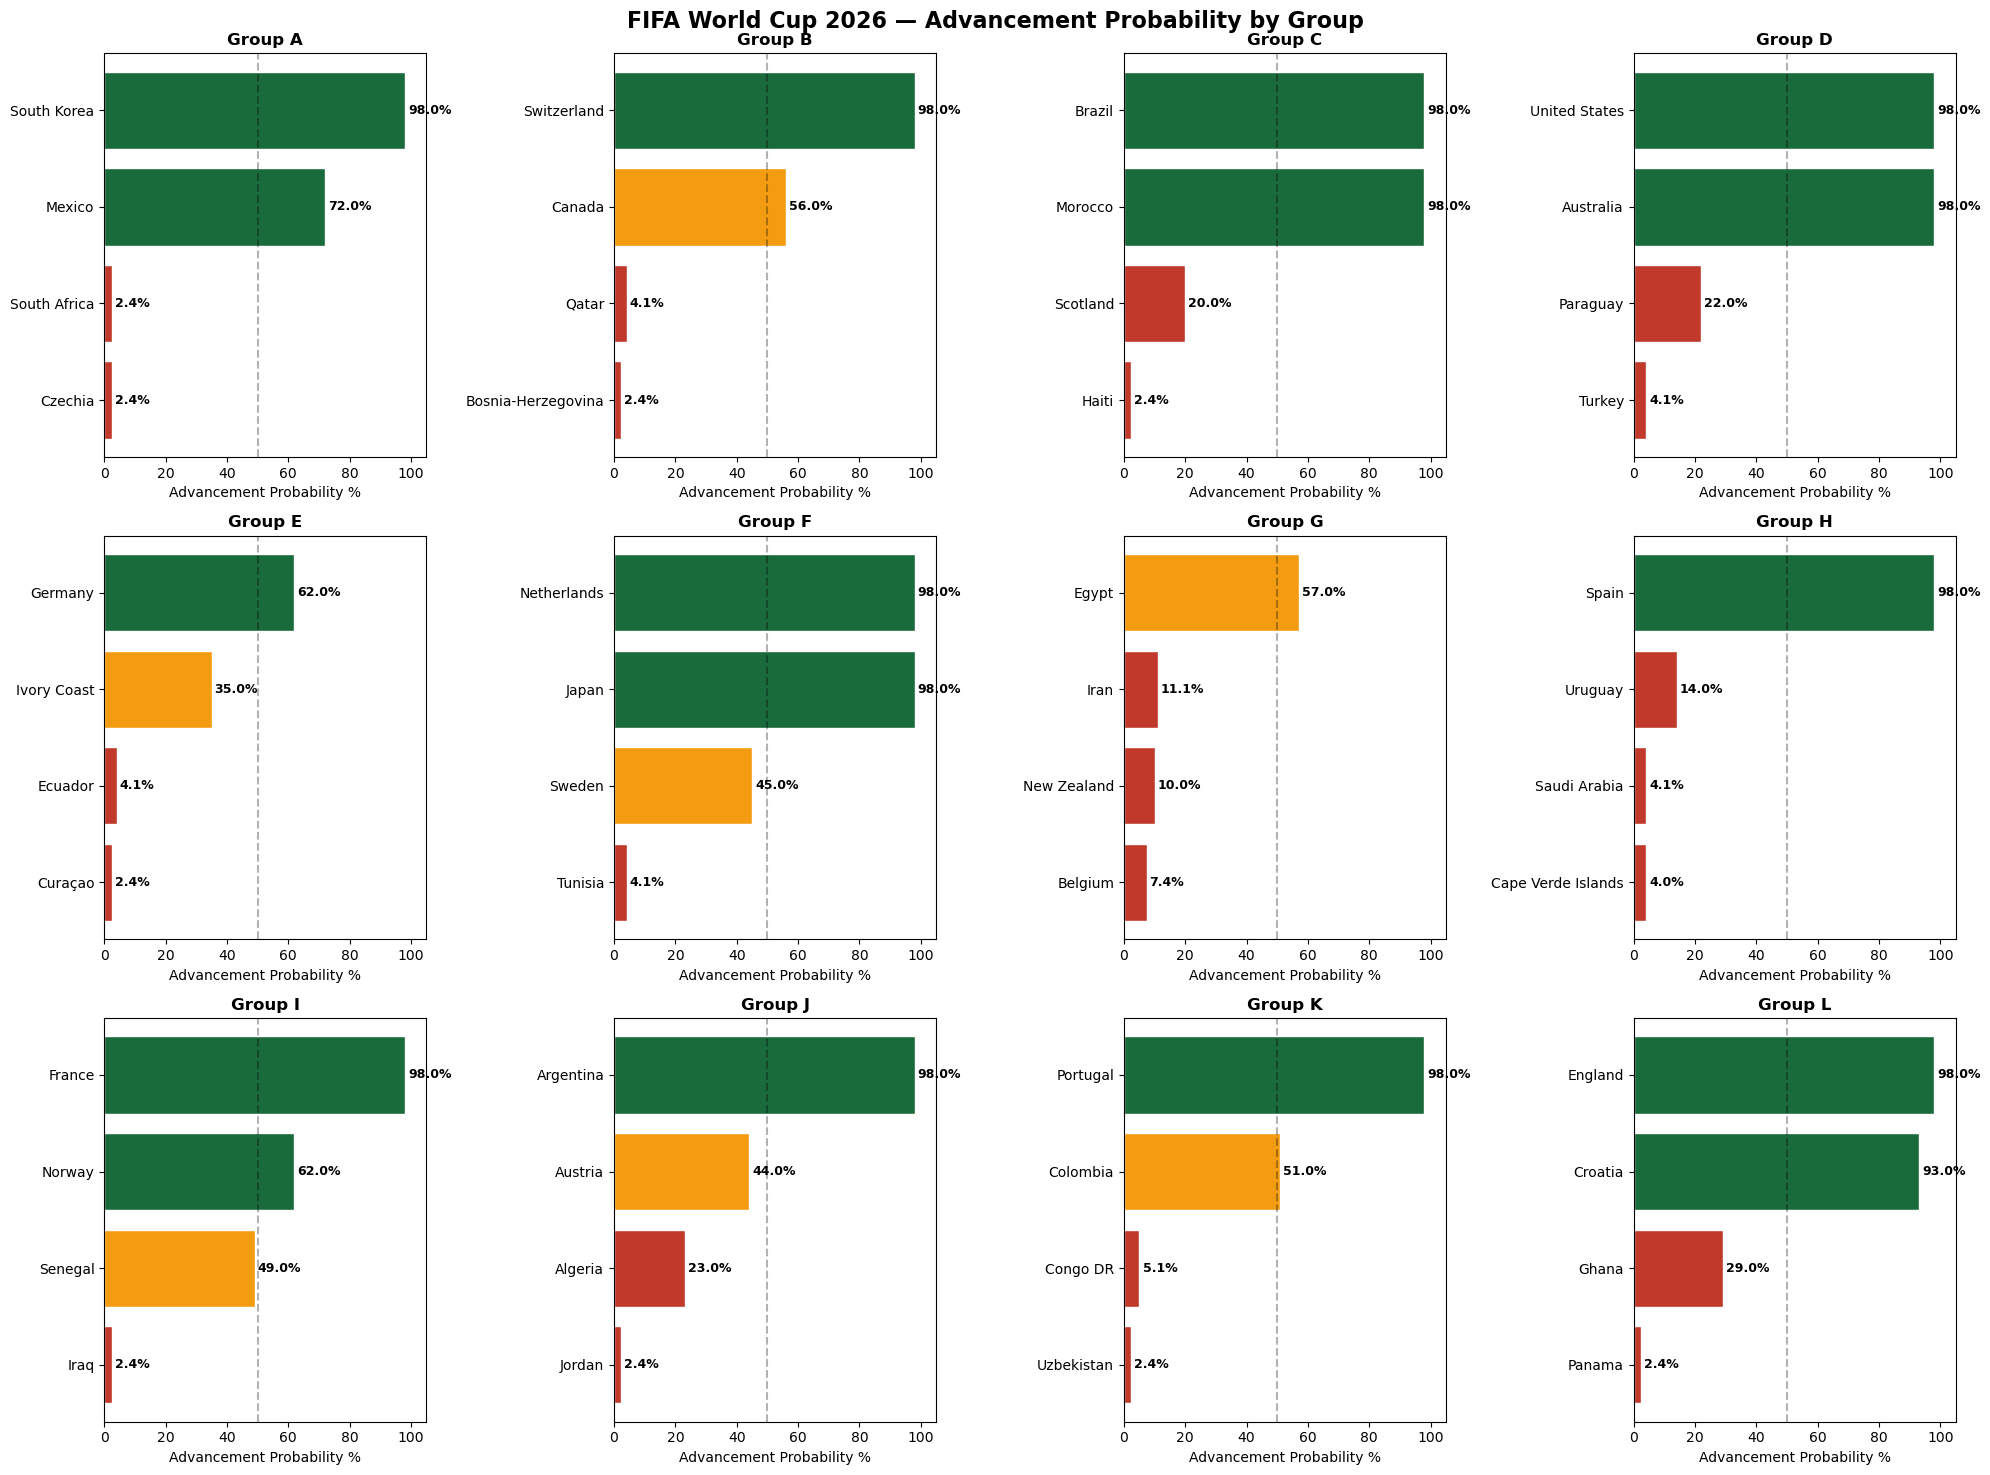

✅ Chart saved — showing 12 groups with matches played


In [7]:
# ============================================
# GROUP BY GROUP BREAKDOWN
# ============================================

groups = sorted(predictions['group'].unique())
n_groups = len(groups)
n_cols = 4
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('FIFA World Cup 2026 — Advancement Probability by Group', 
             fontsize=16, fontweight='bold')
axes = axes.flatten() if n_groups > 1 else [axes]

for idx, group in enumerate(groups):
    ax = axes[idx]
    group_data = predictions[predictions['group'] == group].sort_values(
        'advancement_prob', ascending=True)
    colors = ['#1a6b3c' if p >= 60 else '#f39c12' if p >= 35 else '#c0392b' 
              for p in group_data['advancement_prob_pct']]
    bars = ax.barh(group_data['team'], group_data['advancement_prob_pct'], 
                   color=colors, edgecolor='white')
    ax.set_title(f'Group {group}', fontweight='bold')
    ax.set_xlabel('Advancement Probability %')
    ax.set_xlim(0, 105)
    ax.axvline(x=50, color='black', linestyle='--', alpha=0.3)
    for bar, val in zip(bars, group_data['advancement_prob_pct']):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}%', 
                va='center', fontsize=9, fontweight='bold')

for idx in range(n_groups, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../data/advancement_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved — showing {n_groups} groups with matches played")

### Tournament Winner Probability

🏆 TOP 10 PREDICTED TOURNAMENT WINNERS

Team                    Grp  Rank   Adv%   Win%
-----------------------------------------------------------------
🥇 France                  I     2  98.0%  10.6%
🥈 Spain                   H     3  98.0%   7.3%
🥉 England                 L     4  98.0%   6.1%
 4. Brazil                  C     5  98.0%   5.0%
 5. Portugal                K     6  98.0%   4.4%
 6. Argentina               J     8  98.0%   4.2%
 7. Netherlands             F     7  98.0%   4.0%
 8. Germany                 E    10  62.0%   3.4%
 9. United States           D    14  98.0%   3.3%
 10. Mexico                  A    15  72.0%   3.0%


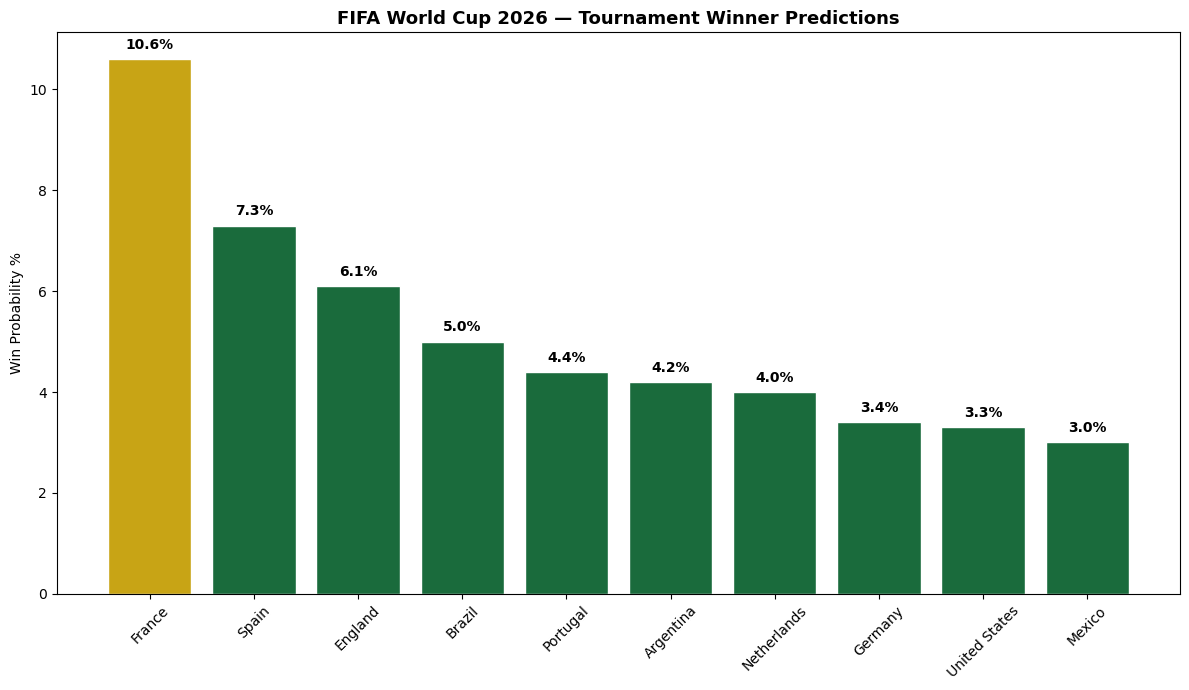


✅ Winner predictions chart saved!


In [8]:
# ============================================
# TOURNAMENT WINNER PROBABILITY
# ============================================

predictions['tournament_score'] = (
    predictions['advancement_prob'] * 0.5 +
    (1 / predictions['fifa_ranking']) * 30 * 0.3 +
    predictions['momentum_score'] * 0.2
)

predictions['win_probability'] = (
    predictions['tournament_score'] / predictions['tournament_score'].sum() * 100
).round(1)

top_contenders = predictions.nlargest(10, 'win_probability')[
    ['team', 'group', 'points', 'fifa_ranking', 'advancement_prob_pct', 'win_probability']
]

print("=" * 65)
print("🏆 TOP 10 PREDICTED TOURNAMENT WINNERS")
print("=" * 65)
print(f"\n{'Team':<22} {'Grp':>4} {'Rank':>5} {'Adv%':>6} {'Win%':>6}")
print("-" * 65)
for i, (_, row) in enumerate(top_contenders.iterrows(), 1):
    medal = "🥇" if i==1 else "🥈" if i==2 else "🥉" if i==3 else f" {i}."
    print(f"{medal} {row['team']:<20} {row['group']:>4} {int(row['fifa_ranking']):>5} "
          f"{row['advancement_prob_pct']:>5}% {row['win_probability']:>5}%")

fig, ax = plt.subplots(figsize=(12, 7))
colors_win = ['#c8a415' if i==0 else '#1a6b3c' for i in range(len(top_contenders))]
bars = ax.bar(top_contenders['team'], top_contenders['win_probability'], 
              color=colors_win, edgecolor='white')
ax.set_title('FIFA World Cup 2026 — Tournament Winner Predictions', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Win Probability %')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_contenders['win_probability']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val}%', 
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/winner_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Winner predictions chart saved!")

In [10]:
# ============================================================
# MONTE CARLO BRACKET SIMULATOR v2
# ============================================================
# How it works:
# 1. Use each team's strength score (form + ranking + momentum)
# 2. Simulate the entire knockout bracket 10,000 times
# 3. In each match, stronger team wins with higher probability
#    but upsets are possible (0.65 compression factor)
# 4. Count how many times each team wins the tournament
# 5. That count / 10,000 = realistic win probability
#
# Better than old formula because:
# - France meeting Brazil in QF hurts both their chances
# - Argentina in good form gets properly rewarded
# - Bracket path matters — easy half = higher probability
# - Eliminated teams immediately drop to 0%
# ============================================================

import numpy as np

N_SIMULATIONS = 10000
np.random.seed(42)

# ── STEP 1: Build team strength scores ──────────────────────
# Rebalanced: 60% current form, 25% FIFA ranking, 15% momentum
# This makes current form matter much more than old formula

predictions['mc_strength'] = (
    predictions['advancement_prob'] * 0.60 +
    (1 / predictions['fifa_ranking']) * 30 * 0.25 +
    predictions['momentum_score'] * 0.15
)

strength = dict(zip(predictions['team'], predictions['mc_strength']))

# ── STEP 2: Match simulator with upset factor ────────────────
def simulate_match(team_a, team_b):
    """
    Simulate a single knockout match.
    Upset factor (0.65 compression) keeps results realistic —
    knockout football is unpredictable, any team can win on the day.
    """
    sa = strength.get(team_a, 0.01)
    sb = strength.get(team_b, 0.01)
    total = sa + sb
    prob_a_wins = sa / total
    # Compress towards 50/50 — prevents dominant teams from
    # winning 95%+ of simulated matches
    prob_a_wins = 0.5 + (prob_a_wins - 0.5) * 0.65
    return team_a if np.random.random() < prob_a_wins else team_b

# ── STEP 3: Group qualifier selector ────────────────────────
def get_group_qualifiers(predictions_df):
    """
    For each group pick top 2 qualifiers probabilistically.
    Allows occasional upset qualifier to reflect real uncertainty.
    Returns dict: group -> [1st place team, 2nd place team]
    """
    qualifiers = {}
    for group in predictions_df['group'].unique():
        group_teams = predictions_df[
            predictions_df['group'] == group
        ].copy().sort_values('advancement_prob', ascending=False)

        teams = group_teams['team'].tolist()
        probs = group_teams['advancement_prob'].values
        probs = np.clip(probs, 0.01, None)

        # Top 2 most likely qualifiers
        top2_teams = teams[:2]
        top2_probs = probs[:2] / probs[:2].sum()

        # 1st place: weighted random between top 2
        first = np.random.choice(top2_teams, p=top2_probs)
        second = [t for t in top2_teams if t != first][0]

        qualifiers[group] = [first, second]

    return qualifiers

# ── STEP 4: WC 2026 bracket structure ───────────────────────
# 48 teams, 12 groups (A-L)
# R32 pairings: 1st of group vs 2nd of adjacent group
BRACKET_PAIRS = [
    ('A', 1, 'B', 2),
    ('B', 1, 'A', 2),
    ('C', 1, 'D', 2),
    ('D', 1, 'C', 2),
    ('E', 1, 'F', 2),
    ('F', 1, 'E', 2),
    ('G', 1, 'H', 2),
    ('H', 1, 'G', 2),
    ('I', 1, 'J', 2),
    ('J', 1, 'I', 2),
    ('K', 1, 'L', 2),
    ('L', 1, 'K', 2),
]

def simulate_knockout_bracket(qualifiers):
    """Simulate full knockout from R32 to Final. Returns champion."""
    # Build R32 matchups
    r32 = []
    for (g1, pos1, g2, pos2) in BRACKET_PAIRS:
        team1 = qualifiers.get(g1, ['TBD', 'TBD'])[pos1 - 1]
        team2 = qualifiers.get(g2, ['TBD', 'TBD'])[pos2 - 1]
        r32.append((team1, team2))

    # Simulate rounds until one team remains
    current_round = r32
    while len(current_round) > 1:
        next_round = []
        for i in range(0, len(current_round), 2):
            winner1 = simulate_match(
                current_round[i][0], current_round[i][1]
            )
            if i + 1 < len(current_round):
                winner2 = simulate_match(
                    current_round[i+1][0], current_round[i+1][1]
                )
                next_round.append((winner1, winner2))
            else:
                next_round.append((winner1, winner1))
        current_round = next_round

    # Final match
    if current_round:
        final = current_round[0]
        return simulate_match(final[0], final[1])
    return None

# ── STEP 5: Run 10,000 simulations ──────────────────────────
print("🎲 Running Monte Carlo bracket simulation...")
print(f"   {N_SIMULATIONS:,} simulations × full tournament bracket")
print(f"   Upset compression factor: 0.65 (realistic knockout football)")
print()

win_counts = {team: 0 for team in predictions['team']}

for sim in range(N_SIMULATIONS):
    qualifiers = get_group_qualifiers(predictions)
    winner = simulate_knockout_bracket(qualifiers)
    if winner and winner in win_counts:
        win_counts[winner] += 1

# ── STEP 6: Convert to percentages ──────────────────────────
monte_carlo_probs = {
    team: round(count / N_SIMULATIONS * 100, 1)
    for team, count in win_counts.items()
}

predictions['mc_win_probability'] = (
    predictions['team'].map(monte_carlo_probs).fillna(0.0)
)

# ── STEP 7: Show results ─────────────────────────────────────
print("=" * 62)
print("🏆 MONTE CARLO TOURNAMENT WINNER PREDICTIONS")
print(f"   Based on {N_SIMULATIONS:,} simulated tournaments")
print("=" * 62)
print(f"\n{'Rank':<5} {'Team':<22} {'Grp':>4} {'Old%':>6} {'MC%':>6}")
print("-" * 62)

mc_sorted = predictions.sort_values(
    'mc_win_probability', ascending=False
).head(15)

for i, (_, row) in enumerate(mc_sorted.iterrows(), 1):
    medal = "🥇" if i==1 else "🥈" if i==2 else "🥉" if i==3 else f" {i:2}."
    old_prob = row['win_probability']
    mc_prob  = row['mc_win_probability']
    change   = "▲" if mc_prob > old_prob else "▼" if mc_prob < old_prob else "─"
    print(
        f"{medal}  {row['team']:<20} {row['group']:>4} "
        f"{old_prob:>5}% {mc_prob:>5}% {change}"
    )

print()
print("▲ = probability increased vs old model")
print("▼ = probability decreased vs old model")
print()

# Quick sanity check
total = predictions['mc_win_probability'].sum()
print(f"✅ Total probability: {total:.1f}% (should be ~100%)")

🎲 Running Monte Carlo bracket simulation...
   10,000 simulations × full tournament bracket
   Upset compression factor: 0.65 (realistic knockout football)

🏆 MONTE CARLO TOURNAMENT WINNER PREDICTIONS
   Based on 10,000 simulated tournaments

Rank  Team                    Grp   Old%    MC%
--------------------------------------------------------------
🥇  France                  I  10.6%  19.3% ▲
🥈  England                 L   6.1%  11.0% ▲
🥉  Spain                   H   7.3%  10.9% ▲
  4.  Portugal                K   4.4%   7.4% ▲
  5.  Argentina               J   4.2%   6.6% ▲
  6.  Brazil                  C   5.0%   5.9% ▲
  7.  Netherlands             F   4.0%   4.6% ▲
  8.  Colombia                K   2.5%   3.4% ▲
  9.  Croatia                 L   2.3%   3.2% ▲
 10.  Germany                 E   3.4%   3.0% ▼
 11.  Norway                  I   2.2%   2.7% ▲
 12.  United States           D   3.3%   2.7% ▼
 13.  Switzerland             B   2.7%   2.5% ▼
 14.  Morocco                 C

In [11]:
# ============================================
# CELL 9 — SAVE PREDICTIONS TO AZURE SQL
# ============================================

import pyodbc
from datetime import datetime

def get_connection():
    connection_string = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={os.getenv('DB_SERVER')},1433;"
        f"DATABASE={os.getenv('DB_NAME')};"
        f"UID={os.getenv('DB_USERNAME')};"
        f"PWD={os.getenv('DB_PASSWORD')};"
        f"Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30;"
    )
    return pyodbc.connect(connection_string)

def save_predictions(predictions_df):
    conn = get_connection()
    cursor = conn.cursor()
    
    # Clear existing predictions first
    cursor.execute("DELETE FROM predictions")
    print(f"🗑️  Cleared old predictions")
    
    # Insert fresh predictions
    inserted = 0
    for _, row in predictions_df.iterrows():
        cursor.execute("""
            INSERT INTO predictions (
                team_name, group_name, played, points,
                goal_difference, goals_for, goals_per_game,
                fifa_ranking, momentum_score,
                advancement_prob, advancement_prob_pct,
                win_probability, updated_at
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """,
        row['team'],
        row['group'],
        int(row['played']),
        int(row['points']),
        int(row['goal_difference']),
        int(row['goals_for']),
        float(row['goals_per_game']),
        int(row['fifa_ranking']),
        float(row.get('momentum_score', 0)),
        float(row['advancement_prob']),
        float(row['advancement_prob_pct']),
        float(row['mc_win_probability']),
        datetime.now()
        )
        inserted += 1
    
    conn.commit()
    conn.close()
    print(f"✅ Saved {inserted} team predictions to Azure SQL")
    print(f"   Updated at: {datetime.now().strftime('%d %b %Y %H:%M')}")

save_predictions(predictions)

# Verify
conn = get_connection()
count = pd.read_sql("SELECT COUNT(*) as cnt FROM predictions", conn).iloc[0]['cnt']
top3 = pd.read_sql("""
    SELECT team_name, advancement_prob_pct, win_probability 
    FROM predictions 
    ORDER BY win_probability DESC
""", conn).head(3)
conn.close()

print(f"\n📊 Verification — {count} predictions in Azure SQL")
print(f"\n🏆 Top 3 predicted winners:")
for i, (_, row) in enumerate(top3.iterrows(), 1):
    medal = "🥇" if i==1 else "🥈" if i==2 else "🥉"
    print(f"   {medal} {row['team_name']} — Win: {row['win_probability']}% | Adv: {row['advancement_prob_pct']}%")

🗑️  Cleared old predictions
✅ Saved 48 team predictions to Azure SQL
   Updated at: 24 Jun 2026 02:16

📊 Verification — 48 predictions in Azure SQL

🏆 Top 3 predicted winners:
   🥇 France — Win: 19.3% | Adv: 98.0%
   🥈 England — Win: 11.0% | Adv: 98.0%
   🥉 Spain — Win: 10.9% | Adv: 98.0%
